In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("Titanic-Dataset.csv")

In [4]:
print(df.shape)

(891, 12)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [6]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
#showing percentage of null values
df.isna().sum()*100/df.shape[0]

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [8]:
#here "Embarked" column has less than 5% data is null,that rows are removed
df=df.dropna(subset=["Embarked"])

In [9]:
# here "Cabin" column has greater than 30% data is null,that column will be removed and not important our data
df=df.drop(columns=["Cabin"])

In [10]:
'''here "Age" column has a less than 30% is null,
that the null rows to fill 'mode' of itself column,
the Age has most repeated once travel,
if we choose others(mean,median) it came with float values age doesn't float
'''
df["Age"]=df["Age"].fillna(df["Age"].mode()[0])

In [11]:
#"Age" is a must be an integer not in float
df["Age"] = df["Age"].astype(int)

Matplotlib is building the font cache; this may take a moment.


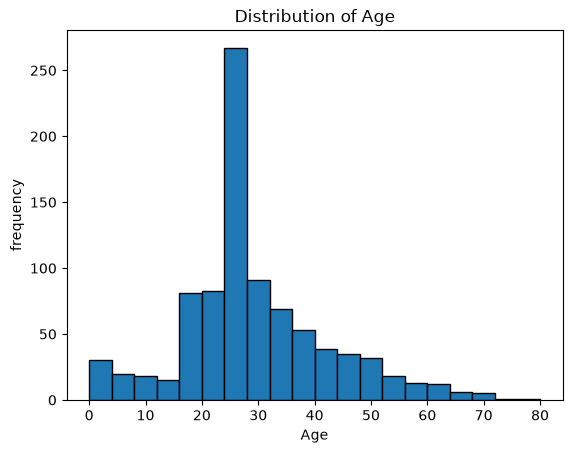

In [12]:
import matplotlib.pyplot as plt
plt.hist(df["Age"],edgecolor="black",bins=20)
plt.xlabel("Age")
plt.ylabel("frequency")
plt.title("Distribution of Age")
plt.show()

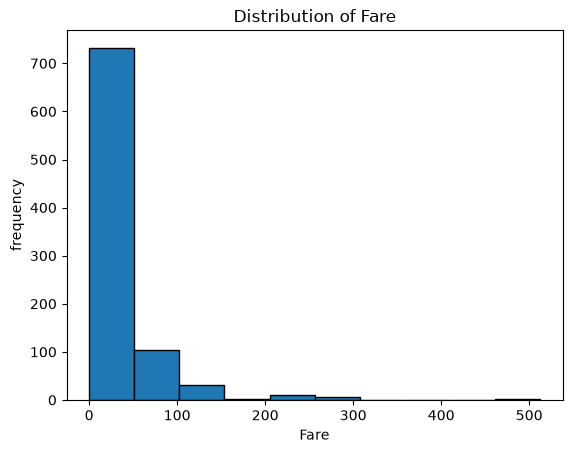

In [13]:
plt.hist(df["Fare"],edgecolor="black")
plt.xlabel("Fare")
plt.ylabel("frequency")
plt.title("Distribution of Fare")
plt.show()

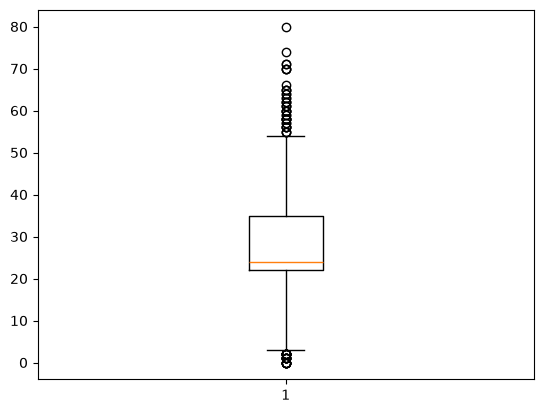

In [14]:
plt.boxplot(df["Age"])
plt.show()

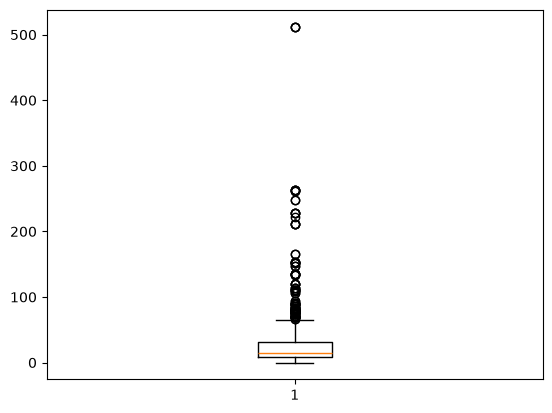

In [15]:
plt.boxplot(df["Fare"])
plt.show()

In [16]:
# Select numerical columns
numeric_columns = df.select_dtypes(include="number").columns
# Calculate and print outliers for each numerical column
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) |(df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers")

PassengerId: 0 outliers
Survived: 0 outliers
Pclass: 0 outliers
Age: 65 outliers
SibSp: 46 outliers
Parch: 213 outliers
Fare: 114 outliers


In [17]:
# Survival rate by Sex
male = df[df["Sex"] == "male"]["Survived"].mean() * 100
female = df[df["Sex"] == "female"]["Survived"].mean() * 100
print("Male survival rate:", round(male, 2), "%")
print("Female survival rate:", round(female, 2), "%")
# Survival rate by Pclass
class1 = df[df["Pclass"] == 1]["Survived"].mean() * 100
class2 = df[df["Pclass"] == 2]["Survived"].mean() * 100
class3 = df[df["Pclass"] == 3]["Survived"].mean() * 100
print("Class 1 survival rate:", round(class1, 2), "%")
print("Class 2 survival rate:", round(class2, 2), "%")
print("Class 3 survival rate:", round(class3, 2), "%")
# Survival rate by Sex and Pclass
female_class1 = df[
    (df["Sex"] == "female") & (df["Pclass"] == 1)
]["Survived"].mean() * 100
female_class2 = df[
    (df["Sex"] == "female") & (df["Pclass"] == 2)
]["Survived"].mean() * 100
female_class3 = df[
    (df["Sex"] == "female") & (df["Pclass"] == 3)
]["Survived"].mean() * 100
male_class1 = df[
    (df["Sex"] == "male") & (df["Pclass"] == 1)
]["Survived"].mean() * 100
male_class2 = df[
    (df["Sex"] == "male") & (df["Pclass"] == 2)
]["Survived"].mean() * 100
male_class3 = df[
    (df["Sex"] == "male") & (df["Pclass"] == 3)
]["Survived"].mean() * 100
print("Female Class 1:", round(female_class1, 2), "%")
print("Female Class 2:", round(female_class2, 2), "%")
print("Female Class 3:", round(female_class3, 2), "%")
print("Male Class 1:", round(male_class1, 2), "%")
print("Male Class 2:", round(male_class2, 2), "%")
print("Male Class 3:", round(male_class3, 2), "%")

Male survival rate: 18.89 %
Female survival rate: 74.04 %
Class 1 survival rate: 62.62 %
Class 2 survival rate: 47.28 %
Class 3 survival rate: 24.24 %
Female Class 1: 96.74 %
Female Class 2: 92.11 %
Female Class 3: 50.0 %
Male Class 1: 36.89 %
Male Class 2: 15.74 %
Male Class 3: 13.54 %


In [18]:
corr_matrix = df.select_dtypes(include="number").corr()

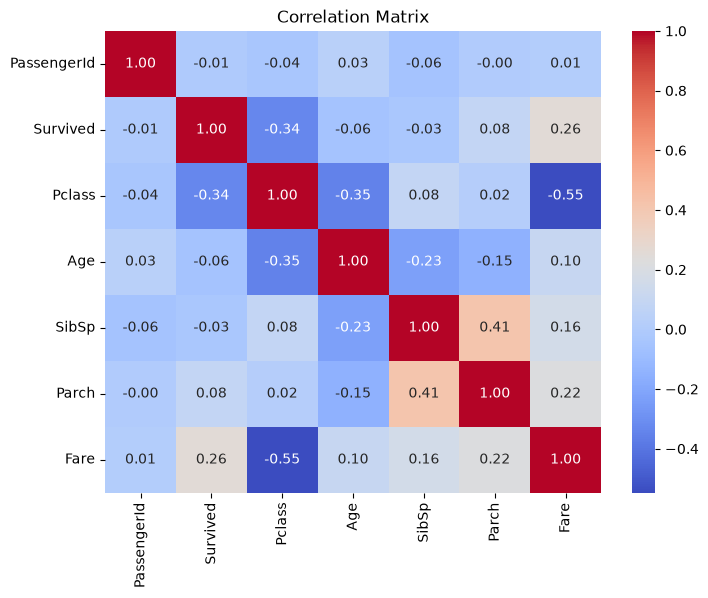

In [19]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [20]:
# Convert correlation matrix into long format
corr_pairs = corr_matrix.unstack()
# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
# Remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()
# Sort by absolute correlation
top2 = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(2)
print("Top 2 strongest correlations:")
print(top2)

Top 2 strongest correlations:
Pclass  Fare    -0.548193
SibSp   Parch    0.414542
dtype: float64


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])
print("Before Scaling")
print(df[["Age", "Fare"]].agg(["mean", "std"]))
print("\nAfter Scaling")
print(df_scaled[["Age", "Fare"]].agg(["mean", "std"]))

Before Scaling
            Age       Fare
mean  28.502812  32.096681
std   13.170240  49.697504

After Scaling
               Age          Fare
mean  5.195194e-17  1.398706e-16
std   1.000563e+00  1.000563e+00


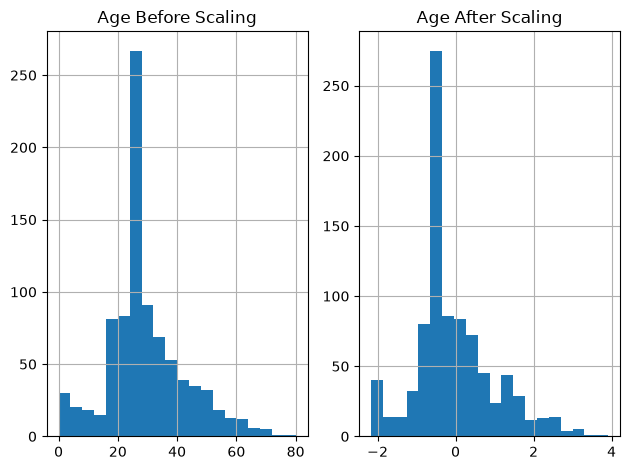

In [22]:
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
df["Age"].hist(bins=20)
plt.title("Age Before Scaling")
plt.subplot(1,2,2)
df_scaled["Age"].hist(bins=20)
plt.title("Age After Scaling")
plt.tight_layout()
plt.show()

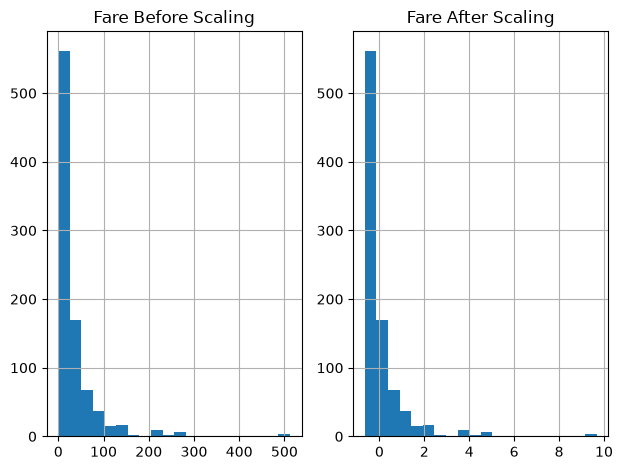

In [23]:
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
df["Fare"].hist(bins=20)
plt.title("Fare Before Scaling")
plt.subplot(1,2,2)
df_scaled["Fare"].hist(bins=20)
plt.title("Fare After Scaling")
plt.tight_layout()
plt.show()